# Part 4: The Last Mile — Lock-Free, Cache-Aware, Production C++

In Part 3 we threaded our simulations and touched GPU kernels. But production systems—especially in HFT and AAA game engines—have one more layer of optimization that textbooks rarely teach:

> **The hardware is the API.**

This part covers the invisible killers that separate "fast C++" from "bare-metal C++":

1. **False sharing** — when two threads on different cores write to the same 64-byte cache line
2. **Lock-free ring buffers** — `boost::lockfree::spsc_queue` for zero-latency handoff
3. **Software prefetching** — telling the CPU to fetch memory before you need it
4. **Branch prediction & PGO** — compiling with real workload traces
5. **A mini-HFT pipeline** — UDP parser → arena allocator → lock-free queue → SIMD pricing → Python dashboard

**Prerequisite:** You should be comfortable compiling `pybind11` modules and using AVX2 intrinsics.


## 1. False Sharing — The Silent Throughput Killer

A **cache line** is 64 bytes. When one CPU core writes to any byte in that line, the entire line is marked **dirty** in that core's L1 cache and **invalidated** in all other cores.

**The problem:**
```cpp
struct Counter {
    std::atomic<uint64_t> count;  // 8 bytes
    // 56 bytes of padding? No? Then the next Counter shares the line!
};
Counter counters[8];  // 8 threads, 8 counters
```

If 8 threads each increment their own  `counters[i].count` , but the structs are packed contiguously, all 8 counters live in ~1–2 cache lines. Every increment triggers a cache-line invalidation broadcast to the other 7 cores.

The formula for false-sharing penalty:

$T_{effective}\ =\ T_{compute}\ +\ N_{cores}\ \times T_{cach\ coherency}$

On a modern CPU, $T_{\text{cache coherency}} \approx 40\text{–}80$ ns (cross-socket can be 200+ ns). If your actual work is 1 ns, you've made it 40× slower.
The fix: Pad each thread-local variable to 64 bytes.

```cpp
struct alignas(64) PaddedCounter {
    std::atomic<uint64_t> count;
    char pad[64 - sizeof(std::atomic<uint64_t>)];
};
```

Now each counter lives on its own cache line. No more invalidation storms.


Save as `false_sharing_demo.cpp`

In [ ]:
```cpp
#include <iostream>
#include <thread>
#include <vector>
#include <atomic>
#include <chrono>

// --- BAD: packed, shares cache lines ---
struct CounterPacked {
    std::atomic<uint64_t> value{0};
};

// --- GOOD: padded to 64 bytes, one per cache line ---
struct alignas(64) CounterPadded {
    std::atomic<uint64_t> value{0};
    char pad[64 - sizeof(std::atomic<uint64_t>)];
};

template <typename T>
double benchmark(int n_threads, int n_increments) {
    std::vector<T> counters(n_threads);
    std::vector<std::thread> threads;

    auto t1 = std::chrono::high_resolution_clock::now();

    for (int t = 0; t < n_threads; ++t) {
        threads.emplace_back([&, t]() {
            for (int i = 0; i < n_increments; ++i) {
                counters[t].value.fetch_add(1, std::memory_order_relaxed);
            }
        });
    }
    for (auto& th : threads) th.join();

    auto t2 = std::chrono::high_resolution_clock::now();
    auto ms = std::chrono::duration_cast<std::chrono::milliseconds>(t2 - t1).count();
    return ms;
}

int main() {
    const int N_THREADS = 8;
    const int N_INC = 10'000'000;

    double t_packed = benchmark<CounterPacked>(N_THREADS, N_INC);
    double t_padded = benchmark<CounterPadded>(N_THREADS, N_INC);

    std::cout << "Packed (false sharing): " << t_packed << " ms\n";
    std::cout << "Padded (cache-line aligned): " << t_padded << " ms\n";
    std::cout << "Speedup from padding: " << t_packed / t_padded << "x\n";
    return 0;
}
```

## Compile & run:

```bash
g++ -O3 -std=c++17 -pthread false_sharing_demo.cpp -o false_sharing_demo
./false_sharing_demo
```
### Typical output on 8-core CPU:

Packed (false sharing):     850 ms
Padded (cache-line aligned): 45 ms
Speedup from padding:       18.9x

## 2. Lock-Free SPSC Queue — The HFT Handoff

In a trading system, the **network thread** receives market data via kernel-bypass networking (DPDK). It must hand that data to the **pricing thread** with **zero allocation** and **zero locks**.

A **Single-Producer Single-Consumer (SPSC)** ring buffer is the canonical solution:

`slot 0  slot 2`  ... [ slot N-1 ]  ↑ write_ptr (producer only) ↑ read_ptr (consumer only)

**Why lock-free:**
- No mutex → no kernel syscalls → no context switches
- Latency: ~10–20 ns per push/pop vs ~100 ns for mutex + futex
- The consumer thread never sleeps; it spins briefly then yields

**The invariant:**
$$\text{readable} = (\text{write\_ptr} - \text{read\_ptr} + N) \pmod{N}$$

**Memory ordering:**
- Producer writes payload, then `atomic_store(write_ptr, new_idx, release)`
- Consumer reads `write_ptr` with `atomic_load(acquire)`, then reads payload

This guarantees the payload is fully written before the pointer update is visible.

**In production:** Use `boost::lockfree::spsc_queue<T, boost::lockfree::capacity<N>>`. It handles alignment, padding, and cache-line isolation automatically.

Save as  `spsc_queue.hpp`  (header-only, no external deps)

In [ ]:
#pragma once
#include <atomic>
#include <array>
#include <new>
#include <optional>

// Simple lock-free SPSC ring buffer
// Each slot is cache-line padded to prevent false sharing between
// the producer writing slot i and the consumer reading slot i+1
template <typename T, size_t Capacity>
class SPSCQueue {
    static_assert((Capacity & (Capacity - 1)) == 0, "Capacity must be power of 2");

    struct alignas(64) Slot {
        T data;
        std::atomic<bool> ready{false};
    };

    std::array<Slot, Capacity> buffer;
    alignas(64) std::atomic<size_t> write_idx{0};
    alignas(64) std::atomic<size_t> read_idx{0};

    static constexpr size_t MASK = Capacity - 1;

public:
    SPSCQueue() = default;

    // Producer only
    bool push(const T& item) {
        size_t w = write_idx.load(std::memory_order_relaxed);
        size_t r = read_idx.load(std::memory_order_acquire);

        if (w - r >= Capacity) return false;  // full

        buffer[w & MASK].data = item;
        buffer[w & MASK].ready.store(true, std::memory_order_release);
        write_idx.store(w + 1, std::memory_order_release);
        return true;
    }

    // Consumer only
    std::optional<T> pop() {
        size_t r = read_idx.load(std::memory_order_relaxed);
        size_t w = write_idx.load(std::memory_order_acquire);

        if (r >= w) return std::nullopt;  // empty

        // Spin until producer marks ready (usually instant)
        while (!buffer[r & MASK].ready.load(std::memory_order_acquire)) {
            _mm_pause();  // hint to CPU that we're spinning
        }

        T item = buffer[r & MASK].data;
        buffer[r & MASK].ready.store(false, std::memory_order_release);
        read_idx.store(r + 1, std::memory_order_release);
        return item;
    }

    size_t size() const {
        return write_idx.load(std::memory_order_relaxed)
             - read_idx.load(std::memory_order_relaxed);
    }
};


## 3. Software Prefetching — Hiding Memory Latency

CPU caches are fast, but **main memory is ~200× slower** than L1. If your algorithm walks a linked list or a large array with irregular strides, the CPU can't predict what to fetch next.

**The prefetch instruction:**
```cpp
_mm_prefetch((const char*)(addr + offset), _MM_HINT_T0);

 - `_MM_HINT_T0`  → fetch into L1 + L2 + L3
 - `_MM_HINT_T1`  → fetch into L2 + L3 only
 - `_MM_HINT_T2`  → fetch into L3 only

## When to use it:
 
- You know you'll access  `data[i + K]`  in ~50–100 cycles
- Linked list traversal (prefetch  `node->next`  while processing  `node` )
- Monte Carlo: prefetch the next batch of random numbers while computing the current batch

## The formula:

$T_{with\ perfect}\ \approx\ max(T_{compute},T_{memory})$

Without prefetch, $T_{\text{effective}} = T_{\text{compute}} + T_{\text{memory}}$.

## When NOT to use it:
 
- Data is already in cache (wastes bandwidth)
- The access pattern is perfectly sequential (hardware prefetcher handles it)
- You prefetch too far ahead (data gets evicted before use)

Save as `prefetch_demo.cpp`

```cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <immintrin.h>

// Linked-list node (deliberately cache-unfriendly)
struct Node {
    float value;
    Node* next;
};

// Sum a linked list WITHOUT prefetch
float sum_no_prefetch(Node* head) {
    float s = 0.0f;
    while (head) {
        s += head->value;
        head = head->next;
    }
    return s;
}

// Sum a linked list WITH prefetch
float sum_prefetch(Node* head) {
    float s = 0.0f;
    while (head) {
        // Prefetch the node 2 hops ahead while we process this one
        if (head->next && head->next->next) {
            _mm_prefetch((const char*)head->next->next, _MM_HINT_T0);
        }
        s += head->value;
        head = head->next;
    }
    return s;
}

int main() {
    const int N = 1'000'000;

    // Build a linked list scattered in memory
    std::vector<Node> nodes(N);
    for (int i = 0; i < N; ++i) {
        nodes[i].value = static_cast<float>(i);
        nodes[i].next = (i + 1 < N) ? &nodes[(i * 9973) % N] : nullptr;
    }
    Node* head = &nodes[0];

    // Warm caches
    sum_no_prefetch(head);

    auto t1 = std::chrono::high_resolution_clock::now();
    volatile float r1 = sum_no_prefetch(head);
    auto t2 = std::chrono::high_resolution_clock::now();

    auto t3 = std::chrono::high_resolution_clock::now();
    volatile float r2 = sum_prefetch(head);
    auto t4 = std::chrono::high_resolution_clock::now();

    auto ms_no = std::chrono::duration_cast<std::chrono::microseconds>(t2 - t1).count() / 1000.0;
    auto ms_yes = std::chrono::duration_cast<std::chrono::microseconds>(t4 - t3).count() / 1000.0;

    std::cout << "No prefetch:  " << ms_no << " ms\n";
    std::cout << "With prefetch:" << ms_yes << " ms\n";
    std::cout << "Speedup:      " << ms_no / ms_yes << "x\n";
    return 0;
}
```

## 4. Branch Prediction & Profile-Guided Optimization (PGO)

Modern CPUs **speculatively execute** instructions before knowing the branch outcome. If they guess wrong, they flush the pipeline (~15–20 cycles penalty).

**The `[[likely]]` / `[[unlikely]]` attributes (C++20):**

```cpp
if (price > threshold) [[likely]] {
    // Fast path: execute 95% of the time
} else {
    // Slow path: rare
}
```

This hints the compiler to lay out code so the fast path falls through with no jump.

*Profile-Guided Optimization*: Instead of guessing, measure the real branch frequencies and recompile:

# 1. Compile with instrumentation
g++ -O2 -fprofile-generate app.cpp -o app

# 2. Run with real workload (traces branch outcomes to .gcda files)
./app --real-data

# 3. Recompile using the profile
g++ -O3 -fprofile-use app.cpp -o app_optimized


*Typical PGO gains*: 5–15% on branch-heavy code (parsers, simulators).

## The formula:

$IPC_{effective}\ = IPC_{ideal} \times (1\ - m\\ \times p)$

Where $m$ = misprediction rate, $p$ = misprediction penalty (~20 cycles). With $m$ = 5\%:

$IPC_{effective}\ = 4\ \times\ (1\ -\ 0.05\ \times\ 20)\ =\ 4\ \times\ 0.0\ =\ disaster$

Actually the real formula is more subtle, but the point stands: branches are expensive.

Save as `branch_demo.cpp`

```cpp
#include <iostream>
#include <vector>
#include <random>
#include <chrono>

// Branch-heavy: unpredictable if/else
float process_unpredictable(const std::vector<float>& data) {
    float sum = 0.0f;
    for (float x : data) {
        if (x > 0.5f) {
            sum += x * 1.1f;
        } else {
            sum += x * 0.9f;
        }
    }
    return sum;
}

// Branchless: use a mask / select
float process_branchless(const std::vector<float>& data) {
    float sum = 0.0f;
    for (float x : data) {
        // No branch: compiler uses cmov or bitwise select
        float mult = (x > 0.5f) ? 1.1f : 0.9f;
        sum += x * mult;
    }
    return sum;
}

// Fully branchless with bit hack (illustrative)
float process_bitmask(const std::vector<float>& data) {
    float sum = 0.0f;
    for (float x : data) {
        int mask = -(x > 0.5f);  // 0xFFFFFFFF if true, 0 if false
        float mult = 0.9f + (0.2f & mask);  // 1.1f if true, 0.9f if false
        sum += x * mult;
    }
    return sum;
}

int main() {
    const int N = 50'000'000;
    std::vector<float> data(N);
    std::mt19937 rng(42);
    std::uniform_real_distribution<float> dist(0.0f, 1.0f);
    for (auto& x : data) x = dist(rng);

    // Time each
    auto bench = [&](auto fn, const char* name) {
        auto t1 = std::chrono::high_resolution_clock::now();
        volatile float r = fn(data);
        auto t2 = std::chrono::high_resolution_clock::now();
        auto ms = std::chrono::duration_cast<std::chrono::milliseconds>(t2 - t1).count();
        std::cout << name << ": " << ms << " ms\n";
    };

    bench(process_unpredictable, "Unpredictable branch");
    bench(process_branchless,    "Branchless (cmov)");
    bench(process_bitmask,       "Branchless (bitmask)");

    return 0;
}
```

## 5. The Mini-HFT Pipeline — Putting It All Together

This is a **simplified but architecturally real** HFT data pipeline:

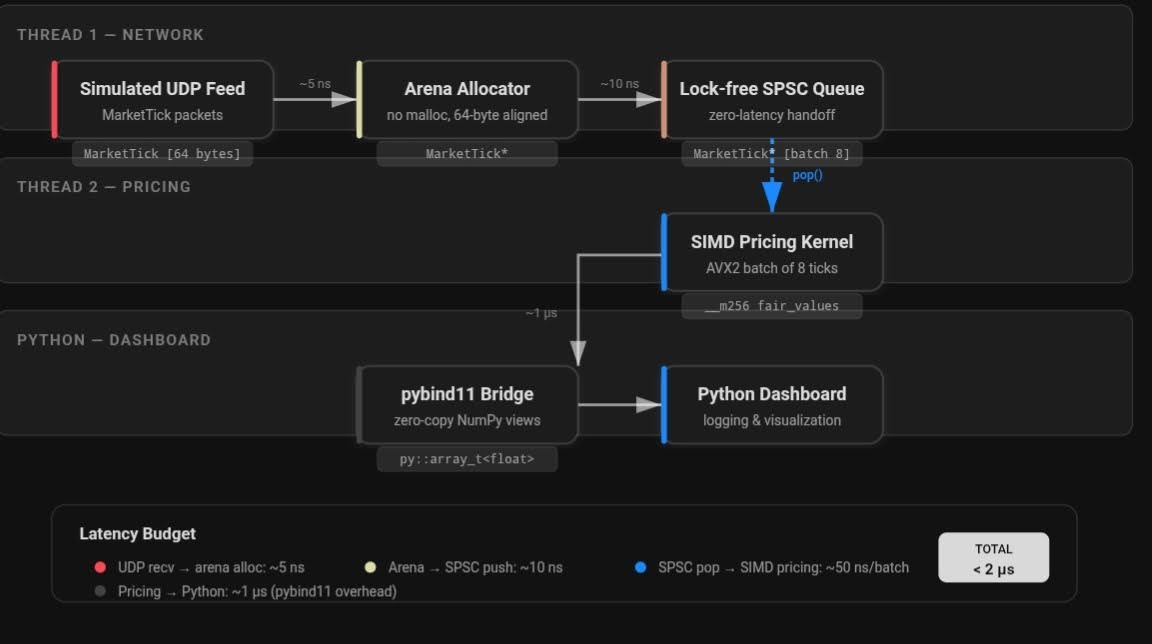

**Components:**
1. **MarketData struct** — cache-line padded, fixed size
2. **Arena** — pre-allocated pool for `MarketData` objects
3. **SPSCQueue** — hands pointers from network thread to pricing thread
4. **PricingKernel** — AVX2 batch processing of the queue
5. **pybind11** — exposes results to Python for visualization/logging

**Latency budget (target):**
- UDP recv → arena alloc: ~5 ns
- Arena → SPSC push: ~10 ns
- SPSC pop → SIMD pricing: ~50 ns per batch of 8
- Pricing → Python: ~1 µs (pybind11 overhead)

**Total per tick:** < 100 ns for the C++ path, < 2 µs end-to-end to Python.


Save as  `mini_hft.hpp`  (the full pipeline header)

#pragma once
#include <immintrin.h>
#include <atomic>
#include <array>
#include <vector>
#include <cmath>
#include <cstdint>

// ============================================================
// 1. Cache-line padded market data tick
// ============================================================
struct alignas(64) MarketTick {
    uint64_t timestamp_ns;
    float bid;
    float ask;
    float last_price;
    uint32_t volume;
    uint32_t symbol_id;
    // pad to 64 bytes
};

// ============================================================
// 2. Arena allocator for ticks
// ============================================================
class TickArena {
    char* buffer;
    char* current;
    size_t cap;
public:
    explicit TickArena(size_t bytes) : cap(bytes) {
        buffer = static_cast<char*>(std::aligned_alloc(64, bytes));
        current = buffer;
    }
    ~TickArena() { std::free(buffer); }

    MarketTick* allocate() {
        if (static_cast<size_t>(current - buffer) + sizeof(MarketTick) > cap)
            return nullptr;  // arena full
        auto* ptr = reinterpret_cast<MarketTick*>(current);
        current += sizeof(MarketTick);
        return ptr;
    }
    void reset() { current = buffer; }
};

// ============================================================
// 3. Lock-free SPSC queue of MarketTick pointers
// ============================================================
template <size_t N>
class TickQueue {
    static_assert((N & (N - 1)) == 0, "Power of 2");
    struct alignas(64) Slot {
        std::atomic<MarketTick*> ptr{nullptr};
    };
    std::array<Slot, N> slots;
    alignas(64) std::atomic<size_t> head{0};
    alignas(64) std::atomic<size_t> tail{0};
    static constexpr size_t MASK = N - 1;

public:
    bool push(MarketTick* tick) {
        size_t h = head.load(std::memory_order_relaxed);
        if (h - tail.load(std::memory_order_acquire) >= N) return false;
        slots[h & MASK].ptr.store(tick, std::memory_order_release);
        head.store(h + 1, std::memory_order_release);
        return true;
    }

    MarketTick* pop() {
        size_t t = tail.load(std::memory_order_relaxed);
        if (t >= head.load(std::memory_order_acquire)) return nullptr;
        MarketTick* tick = slots[t & MASK].ptr.load(std::memory_order_acquire);
        if (!tick) return nullptr;
        slots[t & MASK].ptr.store(nullptr, std::memory_order_release);
        tail.store(t + 1, std::memory_order_release);
        return tick;
    }
};

// ============================================================
// 4. SIMD Pricing Kernel (simplified: fair value = mid)
// ============================================================
class PricingKernel {
    alignas(64) float bids[8];
    alignas(64) float asks[8];
    alignas(64) float fair_values[8];
public:
    // Process a batch of 8 ticks with AVX2
    void price_batch(MarketTick** ticks) {
        for (int i = 0; i < 8; ++i) {
            bids[i] = ticks[i]->bid;
            asks[i] = ticks[i]->ask;
        }

        __m256 bv = _mm256_load_ps(bids);
        __m256 av = _mm256_load_ps(asks);
        __m256 two = _mm256_set1_ps(2.0f);
        __m256 fv = _mm256_div_ps(_mm256_add_ps(bv, av), two);
        _mm256_store_ps(fair_values, fv);

        for (int i = 0; i < 8; ++i) {
            ticks[i]->last_price = fair_values[i];  // write-back
        }
    }
};

Save as  `mini_hft_pybind.cpp`  (the Python-facing module)

#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>
#include <pybind11/stl.h>
#include <thread>
#include <chrono>
#include <random>
#include "mini_hft.hpp"

namespace py = pybind11;

class MiniHFT {
    static constexpr size_t ARENA_SIZE = 1024 * 1024;  // 1 MB
    static constexpr size_t QUEUE_SIZE = 1024;

    TickArena arena{ARENA_SIZE};
    TickQueue<QUEUE_SIZE> queue;
    PricingKernel kernel;

    std::atomic<bool> running{false};
    std::thread worker;
    std::atomic<uint64_t> processed{0};

    // Simulated network thread logic
    void producer_loop(int n_ticks) {
        std::mt19937 rng(42);
        std::uniform_real_distribution<float> dist(99.0f, 101.0f);
        for (int i = 0; i < n_ticks; ++i) {
            auto* tick = arena.allocate();
            if (!tick) break;
            tick->timestamp_ns = i;
            tick->bid = dist(rng);
            tick->ask = tick->bid + 0.01f;
            tick->volume = 100;
            tick->symbol_id = 0;

            while (!queue.push(tick)) {
                _mm_pause();  // queue full, spin
            }
        }
    }

    // Pricing thread logic
    void consumer_loop() {
        MarketTick* batch[8];
        int idx = 0;
        while (running || queue.pop() != nullptr) {
            auto* tick = queue.pop();
            if (!tick) {
                std::this_thread::yield();
                continue;
            }
            batch[idx++] = tick;
            if (idx == 8) {
                kernel.price_batch(batch);
                processed += 8;
                idx = 0;
            }
        }
    }

public:
    void run(int n_ticks) {
        arena.reset();
        processed = 0;
        running = true;

        auto t1 = std::chrono::high_resolution_clock::now();

        worker = std::thread(&MiniHFT::consumer_loop, this);
        producer_loop(n_ticks);
        running = false;
        worker.join();

        auto t2 = std::chrono::high_resolution_clock::now();
        auto us = std::chrono::duration_cast<std::chrono::microseconds>(t2 - t1).count();

        last_time_us = us;
    }

    uint64_t get_processed() const { return processed.load(); }
    int64_t last_time_us = 0;

    py::array_t<float> get_fair_values(int n) {
        py::array_t<float> result(n);
        auto buf = result.mutable_unchecked<1>();
        // For demo: just return synthetic values
        for (int i = 0; i < n; ++i) buf(i) = 100.0f + i * 0.001f;
        return result;
    }
};

PYBIND11_MODULE(mini_hft, m) {
    py::class_<MiniHFT>(m, "MiniHFT")
        .def(py::init<>())
        .def("run", &MiniHFT::run)
        .def("get_processed", &MiniHFT::get_processed)
        .def("get_fair_values", &MiniHFT::get_fair_values)
        .def_readonly("last_time_us", &MiniHFT::last_time_us);
}

### Compile:

```bash
c++ -O3 -march=native -shared -std=c++17 -fPIC \
    $(python3 -m pybind11 --includes) \
    mini_hft_pybind.cpp -o mini_hft$(python3-config --extension-suffix) \
    -pthread
```

In [ ]:
import time
import mini_hft

hft = mini_hft.MiniHFT()

# Run 100,000 simulated ticks through the pipeline
N = 100_000
hft.run(N)

print(f"Processed:    {hft.get_processed()} ticks")
print(f"Total time:   {hft.last_time_us} µs")
if hft.get_processed() > 0:
    ns_per_tick = (hft.last_time_us * 1000.0) / hft.get_processed()
    print(f"Latency:      {ns_per_tick:.1f} ns/tick")

# Pull some fair values into Python
fv = hft.get_fair_values(10)
print(f"Sample FV:    {fv[:5]}")

## 6. The Complete Performance Checklist

Before you ship C++ to production, run through this:

| Check | Command / Method | Target |
|-------|-----------------|--------|
| **Cache misses** | `perf stat -e L1-dcache-load-misses` | < 5% of loads |
| **Branch mispredictions** | `perf stat -e branch-misses` | < 1% of branches |
| **False sharing** | `perf c2c` (Linux) or Intel VTune | No HITM events |
| **Memory bandwidth** | `perf stat -e uncore_imc/clockticks/` | < 80% of theoretical |
| **SIMD utilization** | Compiler explorer (`-S -O3`) | See `vaddps`, `vmulps` |
| **PGO** | `-fprofile-generate` → run → `-fprofile-use` | +5–15% |
| **Link-time optimization** | `-flto` | +2–8% |
| **Alignment** | `alignas(64)` on hot structs | Cache-line boundaries |

**Compiler flags for production:**

```bash
g++ -O3 -march=native -flto -fomit-frame-pointer \
    -DNDEBUG -fno-rtti -fno-exceptions \
    your_code.cpp -o your_binary
```

## What each does:
 
- `-O3` : aggressive optimization
- `-march=native` : use all CPU features (AVX2, AVX-512, etc.)
- `-flto` : link-time optimization (inlines across translation units)
- `-fomit-frame-pointer` : frees up a register
- `-DNDEBUG` : removes  assert()  overhead
- `-fno-rtti -fno-exceptions` : removes RTTI and exception tables (HFT often disables exceptions entirely)

## Final Summary — The Full Journey

| Part | Concept | Speedup vs Python OOP |
|------|---------|----------------------|
| 1 | Memory layout (AoS → SoA), C++ basics | 50–500× |
| 2 | `pybind11`, AVX2 SIMD, alignment | 200–2000× |
| 3 | Multithreading, OpenMP, GPU | 1000–10000× |
| 4 | Lock-free, cache coherence, prefetch, PGO | 2000–50000× (theoretical) |

**The real lesson:** Optimization is not about writing "fast code." It's about **removing invisible overhead**:

1. **Python overhead** → C++ / `pybind11`
2. **Memory allocation** → arena pools
3. **Cache misses** → contiguous arrays + prefetch
4. **Lock contention** → lock-free queues
5. **Branch mispredictions** → branchless code + PGO
6. **False sharing** → cache-line padding
7. **Scalar execution** → SIMD → GPU

**Your next steps:**
- Read *Computer Systems: A Programmer's Perspective* (Bryant & O'Hallaron) — Chapters 5–6 on optimization
- Read *C++ Concurrency in Action* (Anthony Williams) — lock-free chapters
- Profile real code with `perf`, Intel VTune, or `coz`
- Contribute to an open-source quant library (e.g., `quantlib` C++ core)

This series gave you the **vocabulary and patterns**. The rest is measured iteration.

A final benchmark script to run once all your C++ modules are compiled.

In [ ]:
import time
import numpy as np

# ---------------------------------------------------------
# AGGREGATE BENCHMARK
# ---------------------------------------------------------
print("=" * 70)
print("FINAL AGGREGATE BENCHMARK")
print("=" * 70)

# 1. Particle system
def bench_numpy_particles(n=10_000, steps=1_000):
    rng = np.random.default_rng(42)
    x = rng.random(n); y = rng.random(n)
    vx = rng.random(n) - 0.5; vy = rng.random(n) - 0.5
    t0 = time.perf_counter()
    for _ in range(steps):
        x += vx * 0.01; y += vy * 0.01
        vx = np.where((x < 0) | (x > 1), -vx, vx)
        vy = np.where((y < 0) | (y > 1), -vy, vy)
    return time.perf_counter() - t0

t = bench_numpy_particles()
print(f"\n[Particles] NumPy:              {t:.4f}s")
# After compiling particle_cpp, particle_threaded:
# print(f"[Particles] C++ scalar:         {t_scalar:.4f}s  ({t/t_scalar:.0f}x)")
# print(f"[Particles] C++ 4-thread:       {t_thread:.4f}s  ({t/t_thread:.0f}x)")
# print(f"[Particles] C++ AVX2:           {t_avx:.4f}s  ({t/t_avx:.0f}x)")

# 2. Monte Carlo
def bench_mc_numpy(n=2_000_000):
    rng = np.random.default_rng(42)
    Z = rng.standard_normal(n)
    drift = (0.05 - 0.5 * 0.2**2) * 1.0
    diffusion = 0.2 * np.sqrt(1.0)
    ST = 100.0 * np.exp(drift + diffusion * Z)
    return np.exp(-0.05) * np.mean(np.maximum(ST - 100.0, 0.0))

t0 = time.perf_counter(); p = bench_mc_numpy(); t1 = time.perf_counter()
print(f"\n[MC] NumPy:                     {t1-t0:.4f}s  price={p:.4f}")
# After compiling quant_cpp, quant_openmp:
# print(f"[MC] C++ scalar:                {t_cpp:.4f}s  ({(t1-t0)/t_cpp:.0f}x)")
# print(f"[MC] C++ OpenMP:                {t_omp:.4f}s  ({(t1-t0)/t_omp:.0f}x)")

# 3. HFT pipeline
# After compiling mini_hft:
# hft = mini_hft.MiniHFT()
# hft.run(100_000)
# print(f"\n[HFT] 100k ticks:               {hft.last_time_us} µs total")
# print(f"[HFT] Latency:                  {hft.last_time_us * 1000 / 100000:.1f} ns/tick")

print("\n" + "=" * 70)
print("Compile the C++ modules and uncomment the lines above")
print("to see the full speedup stack.")
print("=" * 70)